In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Coursework/Programming for data analytic/healthcare-dataset-stroke-data.csv')

In [4]:
df.stroke.value_counts()

,count
stroke,
0,4861
1,249


# Descriptive analytics

## Basic Statistics

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df.describe(include='object')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


## Visualization

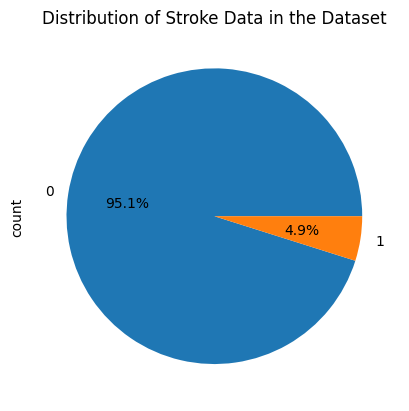

In [8]:
df["stroke"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Distribution of Stroke Data in the Dataset")
plt.show()

Text(0.5, 1.0, 'Exploring Stroke Occurrence Across Different Age Groups')

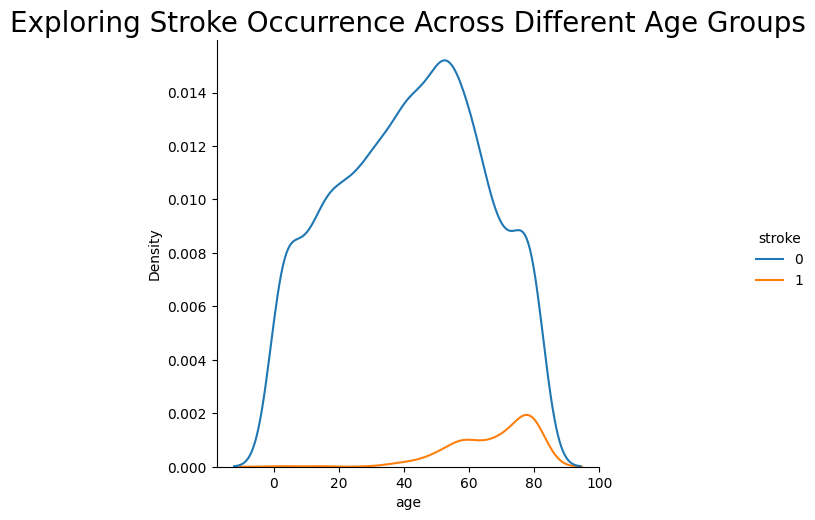

In [9]:
sns.displot(data=df, x="age", hue="stroke", kind="kde")
plt.title("Exploring Stroke Occurrence Across Different Age Groups",fontsize=20)

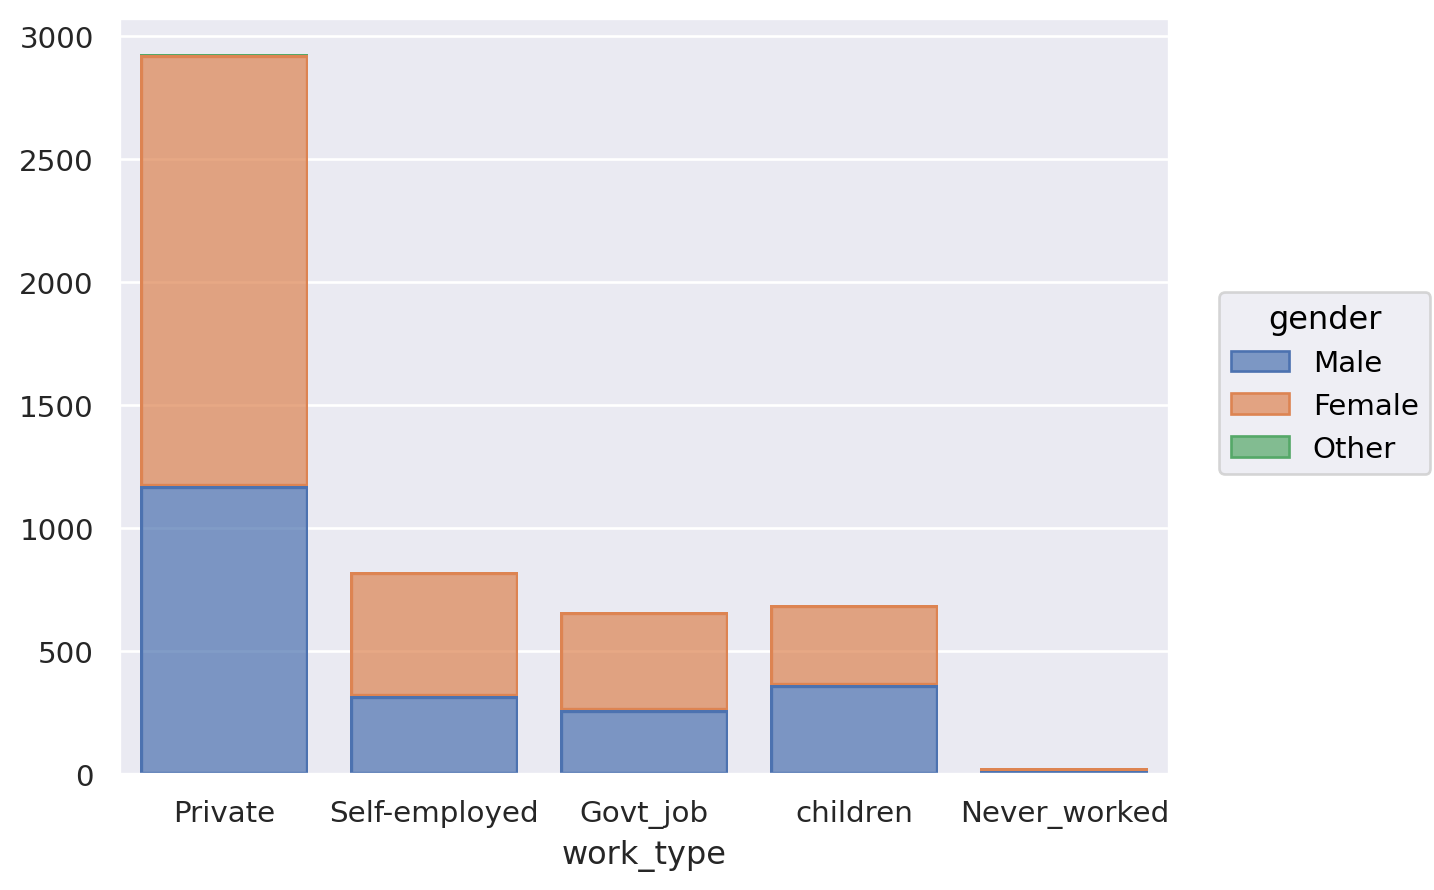

In [10]:
# work_type VS gender
import seaborn.objects as so
so.Plot(df , x ='work_type', color = 'gender').add(so.Bar(),so.Count(),so.Stack())
# Note : the distribution of males and females in different job sectors.

Text(0.5, 1.0, 'Stroke Distribution Based on Residence Type')

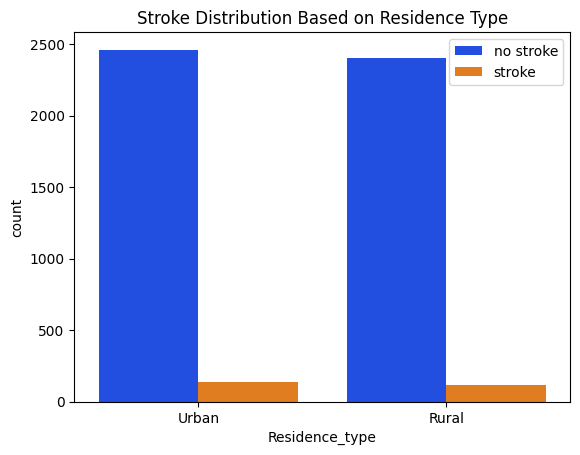

In [11]:
sns.countplot(x="Residence_type", data=df, palette='bright',hue='stroke')
plt.legend(['no stroke','stroke'])
plt.title('Stroke Distribution Based on Residence Type')

<ipython-input-12-ed56b815b05d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="smoking_status", y="stroke", data=df, palette="bright")


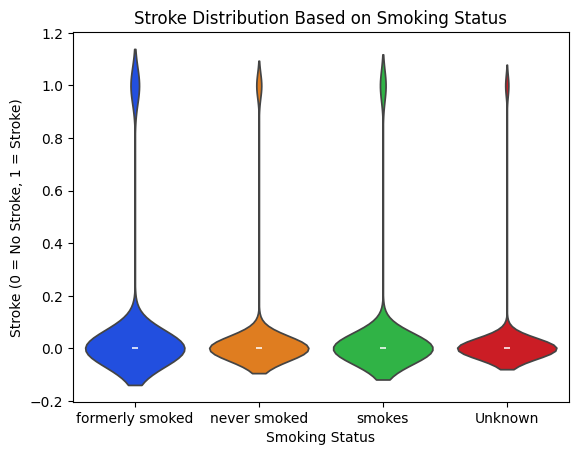

In [12]:
# Create a violin plot
sns.violinplot(x="smoking_status", y="stroke", data=df, palette="bright")

# Add title and labels
plt.title('Stroke Distribution Based on Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke (0 = No Stroke, 1 = Stroke)')
plt.show()

# Data Preparation:

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [14]:
df.duplicated().sum()

0

## Dropping columns:

In [15]:
df.drop(['id'],axis=1,inplace=True)

In [16]:
df.corr(numeric_only=True)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


<Axes: >

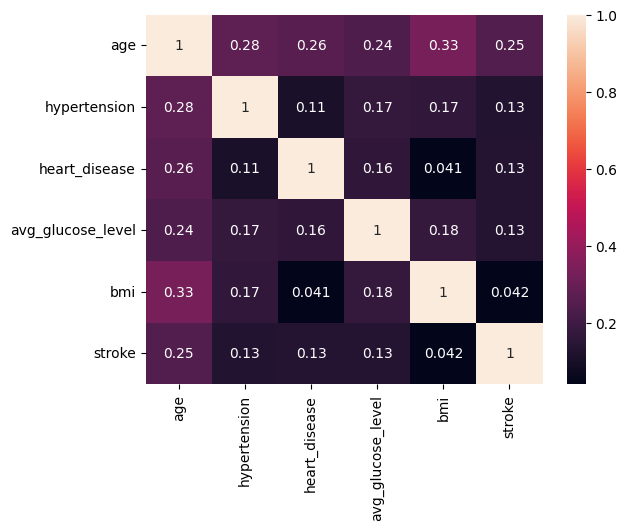

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Handling Missing Values

In [18]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [19]:
bmi_missing_values = df['bmi'].isna().value_counts()
print(f'{round(bmi_missing_values[1]/(bmi_missing_values[0] + bmi_missing_values[1])*100,3)} % of bmi data is missing')

3.933 % of bmi data is missing


<ipython-input-19-4e86af88b514>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'{round(bmi_missing_values[1]/(bmi_missing_values[0] + bmi_missing_values[1])*100,3)} % of bmi data is missing')


In [20]:
df.dropna(inplace= True)

## Outlier

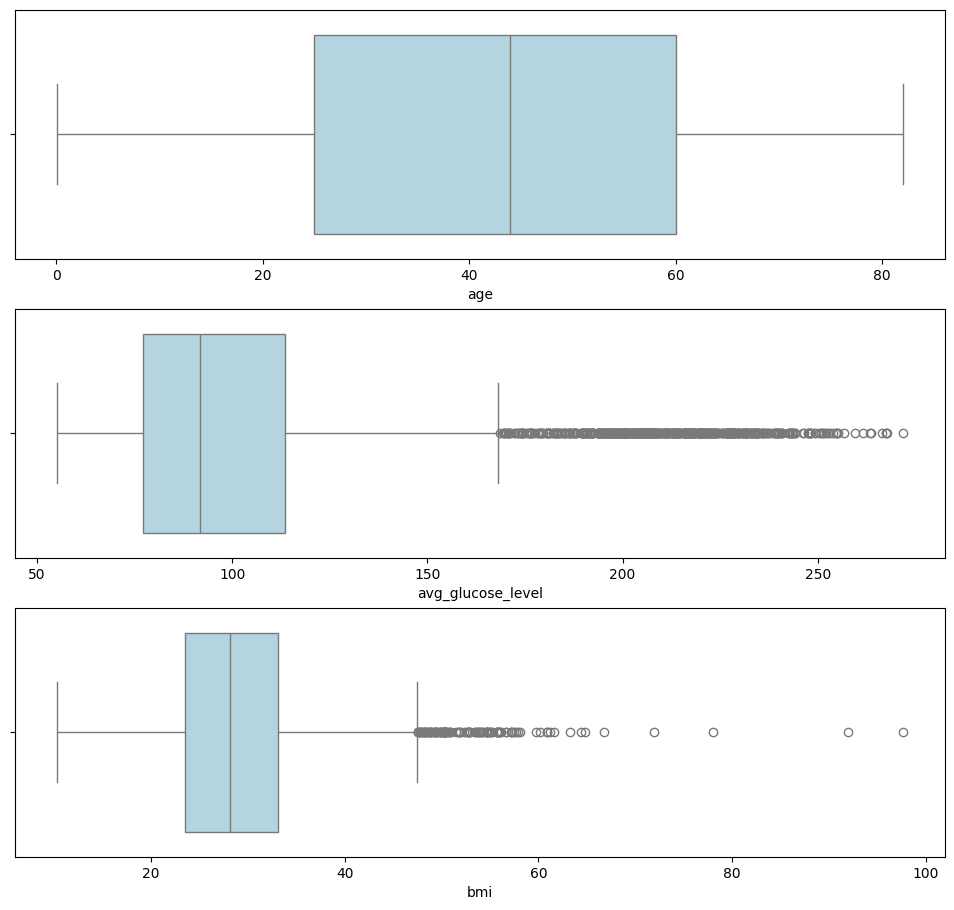

In [21]:
plt.figure(figsize=(12,11))
for i,col in enumerate(df.select_dtypes(float).columns):
    plt.subplot(3,1,i+1)
    sns.boxplot(data=df,x=col,color="lightblue");

In [22]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from column
df = remove_outliers(df, 'avg_glucose_level')
df = remove_outliers(df, 'bmi')

## Discretization

In [23]:
df["age_group"]=df["age"].apply(lambda x:"Infant" if (x>=0)&(x<=2)
                                  else ("Child" if (x>2)&(x<=12)
                                  else ("Adolescent"if (x>12)&(x<=18)
                                  else ("Young Adults"if (x>19)&(x<=35)
                                  else ("Middle Aged Adults" if (x>35)&(x<=60)
                                  else "Old Aged Adults")))))

## Oversampling:

In [24]:
had_stroke = df[df["stroke"]==1]
no_stroke = df[df["stroke"]==0]
# Perform upsampling to balance the data by increasing the number of rows with "stroke" == 1
# The number of rows in the upsampled dataset is made equal to the number of rows where "stroke" == 0
upsampled_had_stroke = resample(had_stroke,replace=True , n_samples=no_stroke.shape[0] , random_state=123 )
upsampled_data = pd.concat([no_stroke,upsampled_had_stroke])

<Axes: ylabel='count'>

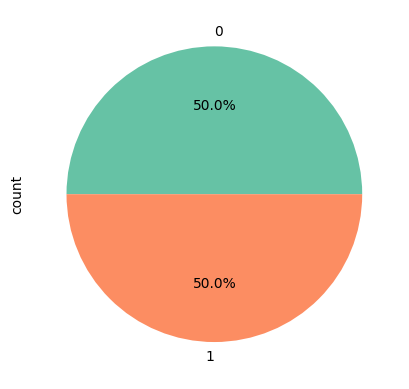

In [25]:
upsampled_data.stroke.value_counts().plot(kind = "pie",autopct="%0.1f%%",colors =sns.color_palette("Set2"))

## Normalization:

In [26]:
scaler = MinMaxScaler()
for col in ['age','avg_glucose_level','bmi']:
    scaler.fit(df[[col]])
    df[col]=scaler.transform(df[[col]])

In [27]:
upsampled_data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
249,Male,3.0,0,0,No,children,Rural,95.12,18.0,Unknown,0,Child
250,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0,Middle Aged Adults
251,Female,8.0,0,0,No,Private,Urban,110.89,17.6,Unknown,0,Child
252,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0,Old Aged Adults
253,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,Unknown,0,Adolescent


## Encoding

In [28]:
encoder = LabelEncoder()
upsampled_data["age_group"] = encoder.fit_transform(upsampled_data["age_group"])
upsampled_data['gender'] = encoder.fit_transform(upsampled_data['gender'])
upsampled_data["hypertension"] = encoder.fit_transform(upsampled_data["hypertension"])
upsampled_data["heart_disease"] = encoder.fit_transform(upsampled_data["heart_disease"])
upsampled_data["ever_married"] = encoder.fit_transform(upsampled_data["ever_married"])
upsampled_data["work_type"] = encoder.fit_transform(upsampled_data["work_type"])
upsampled_data["Residence_type"] = encoder.fit_transform(upsampled_data["Residence_type"])
upsampled_data["smoking_status"] = encoder.fit_transform(upsampled_data["smoking_status"])

In [29]:
cols = ['gender','hypertension','heart_disease', 'ever_married', 'work_type', 'Residence_type','smoking_status']
dums = pd.get_dummies(upsampled_data[cols],dtype=int)
model_data = pd.concat([upsampled_data,dums],axis=1).drop(columns=cols)

In [30]:
model_data = upsampled_data
model_data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
249,1,3.0,0,0,0,4,0,95.12,18.0,0,0,1
250,1,58.0,1,0,1,2,1,87.96,39.2,2,0,3
251,0,8.0,0,0,0,2,1,110.89,17.6,0,0,1
252,0,70.0,0,0,1,2,0,69.04,35.9,1,0,4
253,1,14.0,0,0,0,1,0,161.28,19.1,0,0,0


# **Classification**

In [31]:
from sklearn.model_selection import train_test_split
X = model_data.drop(columns="stroke")
y = model_data["stroke"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7,shuffle=True)

## SVM



*   SVM 1



In [32]:
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn import preprocessing

clf = svm.SVC(kernel='linear')

#fit the clasifier to the data
clf.fit(X_train,y_train)
#predicted values using the knn model
y_pred = clf.predict(X_test)

#performance metrics

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[595 246]
 [154 652]] 

              precision    recall  f1-score   support

           0       0.79      0.71      0.75       841
           1       0.73      0.81      0.77       806

    accuracy                           0.76      1647
   macro avg       0.76      0.76      0.76      1647
weighted avg       0.76      0.76      0.76      1647

Accuracy: 0.7571341833636915
AUC: 0.7582120422632869


*   SVM 2

In [33]:
clf = svm.SVC(kernel='rbf')

#fit the clasifier to the data
clf.fit(X_train,y_train)
#predicted values using the knn model
y_pred = clf.predict(X_test)

#performance metrics

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[537 304]
 [ 98 708]] 

              precision    recall  f1-score   support

           0       0.85      0.64      0.73       841
           1       0.70      0.88      0.78       806

    accuracy                           0.76      1647
   macro avg       0.77      0.76      0.75      1647
weighted avg       0.77      0.76      0.75      1647

Accuracy: 0.75591985428051
AUC: 0.7584687377368902


*   SVM 3

In [34]:
clf = svm.SVC(kernel='sigmoid')

#fit the clasifier to the data
clf.fit(X_train,y_train)
#predicted values using the knn model
y_pred = clf.predict(X_test)

#performance metrics

print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[590 251]
 [215 591]] 

              precision    recall  f1-score   support

           0       0.73      0.70      0.72       841
           1       0.70      0.73      0.72       806

    accuracy                           0.72      1647
   macro avg       0.72      0.72      0.72      1647
weighted avg       0.72      0.72      0.72      1647

Accuracy: 0.7170613236187007
AUC: 0.7173981995910576


## Random Forest

### Model 1

In [35]:
from sklearn.ensemble import RandomForestClassifier

#initialise classifier
RF = RandomForestClassifier(random_state=0, max_depth=10, criterion='gini')

#fit the classifier to the data
RF.fit(X_train, y_train)

#predict the values for the test set
y_pred = RF.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[773  68]
 [  0 806]] 

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       841
           1       0.92      1.00      0.96       806

    accuracy                           0.96      1647
   macro avg       0.96      0.96      0.96      1647
weighted avg       0.96      0.96      0.96      1647

Accuracy: 0.9587128111718276
AUC: 0.9595719381688467


### Model 2


In [36]:
RF = RandomForestClassifier(random_state=0, max_depth=10, n_estimators=150, criterion='entropy')

#fit the classifier to the data
RF.fit(X_train, y_train)

#predict the values for the test set
y_pred = RF.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[772  69]
 [  0 806]] 

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       841
           1       0.92      1.00      0.96       806

    accuracy                           0.96      1647
   macro avg       0.96      0.96      0.96      1647
weighted avg       0.96      0.96      0.96      1647

Accuracy: 0.9581056466302368
AUC: 0.9589774078478002


### Model 3

In [37]:
#RF = RandomForestClassifier(max_depth=10, random_state=0)
RF = RandomForestClassifier(random_state=0, max_depth=5, n_estimators=100, criterion='entropy')

#fit the classifier to the data
RF.fit(X_train, y_train)

#predict the values for the test set
y_pred = RF.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[611 230]
 [ 81 725]] 

              precision    recall  f1-score   support

           0       0.88      0.73      0.80       841
           1       0.76      0.90      0.82       806

    accuracy                           0.81      1647
   macro avg       0.82      0.81      0.81      1647
weighted avg       0.82      0.81      0.81      1647

Accuracy: 0.8111718275652702
AUC: 0.8130098872015177


## MLP Classifier

### Model 1

In [38]:
#import the classifier
from sklearn.neural_network import MLPClassifier

# initialize the classifier
MLP = MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=1000,hidden_layer_sizes=(100,))
#fit the classifier to the data
MLP.fit(X_train, y_train)

#use the resulting model to predict value on the test sey
y_pred = MLP.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[612 229]
 [101 705]] 

              precision    recall  f1-score   support

           0       0.86      0.73      0.79       841
           1       0.75      0.87      0.81       806

    accuracy                           0.80      1647
   macro avg       0.81      0.80      0.80      1647
weighted avg       0.81      0.80      0.80      1647

Accuracy: 0.7996357012750456
AUC: 0.8011974696317452


### Model 2

In [39]:
# initialize the classifier
MLP = MLPClassifier(
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=1000,
    hidden_layer_sizes=(100, 50, 25)  # Three hidden layers with decreasing neurons
)

#fit the classifier to the data
MLP.fit(X_train, y_train)

#use the resulting model to predict value on the test sey
y_pred = MLP.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[720 121]
 [ 24 782]] 

              precision    recall  f1-score   support

           0       0.97      0.86      0.91       841
           1       0.87      0.97      0.92       806

    accuracy                           0.91      1647
   macro avg       0.92      0.91      0.91      1647
weighted avg       0.92      0.91      0.91      1647

Accuracy: 0.9119611414693382
AUC: 0.9131734936844061


### Model 3

In [40]:
# initialize the classifier
MLP = MLPClassifier(activation='tanh',solver='sgd',random_state=42,max_iter=1000,hidden_layer_sizes=(50, 50))  # Two hidden layers with 50 neurons each

#fit the classifier to the data
MLP.fit(X_train, y_train)

#use the resulting model to predict value on the test
y_pred = MLP.predict(X_test)

#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[547 294]
 [ 99 707]] 

              precision    recall  f1-score   support

           0       0.85      0.65      0.74       841
           1       0.71      0.88      0.78       806

    accuracy                           0.76      1647
   macro avg       0.78      0.76      0.76      1647
weighted avg       0.78      0.76      0.76      1647

Accuracy: 0.761384335154827
AUC: 0.7637936935528129


## XgBoost

### Model 1

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [42]:
model = XGBClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[815  26]
 [  0 806]] 

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       841
           1       0.97      1.00      0.98       806

    accuracy                           0.98      1647
   macro avg       0.98      0.98      0.98      1647
weighted avg       0.98      0.98      0.98      1647

Accuracy: 0.98421372191864
AUC: 0.9845422116527943


### Model 2

In [43]:
model = XGBClassifier(max_depth=10,n_estimators=200,learning_rate=0.1)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[822  19]
 [  0 806]] 

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       841
           1       0.98      1.00      0.99       806

    accuracy                           0.99      1647
   macro avg       0.99      0.99      0.99      1647
weighted avg       0.99      0.99      0.99      1647

Accuracy: 0.9884638737097754
AUC: 0.988703923900119


### Model 3

In [44]:
model = XGBClassifier(max_depth=6,n_estimators=100,learning_rate=0.05)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[735 106]
 [  5 801]] 

              precision    recall  f1-score   support

           0       0.99      0.87      0.93       841
           1       0.88      0.99      0.94       806

    accuracy                           0.93      1647
   macro avg       0.94      0.93      0.93      1647
weighted avg       0.94      0.93      0.93      1647

Accuracy: 0.9326047358834244
AUC: 0.9338780489963798


# **Regression**

In [45]:
model_data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
249,1,3.0,0,0,0,4,0,95.12,18.0,0,0,1
250,1,58.0,1,0,1,2,1,87.96,39.2,2,0,3
251,0,8.0,0,0,0,2,1,110.89,17.6,0,0,1
252,0,70.0,0,0,1,2,0,69.04,35.9,1,0,4
253,1,14.0,0,0,0,1,0,161.28,19.1,0,0,0


In [46]:
X = model_data.drop(columns="bmi")
y = model_data["bmi"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7,shuffle=True)

##   Linear Regression



In [47]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

# initialize the Naive Bayes classifier
LR = LinearRegression()

#fit the classifier to the data
LR.fit(X_train,y_train)

#use the resulting model to predict value on the test sey
y_pred = LR.predict(X_test)


print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)), '\n')
print("R2 score:", r2_score(y_test, y_pred))

Mean Absolute Error: 4.6827678232196535
Mean Squared Error: 34.335908912198235
Root Mean Squared Error: 5.859685052304282 

R2 score: 0.10310110046333598


##   CatBoost





In [48]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 9.1 MB/s eta 0:00:00


In [49]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, f1_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

cb_model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
cb_model.fit(X_train, y_train)
preds = cb_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, preds))
print('MSE:', mean_squared_error(y_test, preds))
print('RMSE:', np.sqrt(mean_squared_error(y_test, preds)))
cb_r2_score=r2_score(y_test, preds)
print('r2_score',cb_r2_score)

MAE: 2.608356342854791
MSE: 18.077190334119003
RMSE: 4.251727923341168
r2_score 0.5278001185625772


# Clustering

## Kmeans

In [50]:
model_data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
249,1,3.0,0,0,0,4,0,95.12,18.0,0,0,1
250,1,58.0,1,0,1,2,1,87.96,39.2,2,0,3
251,0,8.0,0,0,0,2,1,110.89,17.6,0,0,1
252,0,70.0,0,0,1,2,0,69.04,35.9,1,0,4
253,1,14.0,0,0,0,1,0,161.28,19.1,0,0,0


In [51]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(model_data)

KMeans(n_clusters=2, random_state=0)

In [52]:
kmeans.cluster_centers_

array([[4.23034330e-01, 6.69664083e+01, 2.05980066e-01, 1.23477298e-01,
        8.76522702e-01, 1.97655962e+00, 5.12366187e-01, 9.42279402e+01,
        2.92338501e+01, 1.55389443e+00, 6.90291621e-01, 3.64082687e+00],
       [3.72778962e-01, 2.66899360e+01, 3.30490405e-02, 2.48756219e-03,
        4.58777541e-01, 2.40191898e+00, 5.01421464e-01, 8.75469474e+01,
        2.67154584e+01, 1.26936745e+00, 1.33617626e-01, 2.93141436e+00]])

In [53]:
# Compute the silhouette score
from sklearn.metrics import silhouette_score
kmeans_silhouette = silhouette_score(model_data, kmeans.labels_).round(2)
kmeans_silhouette

0.35

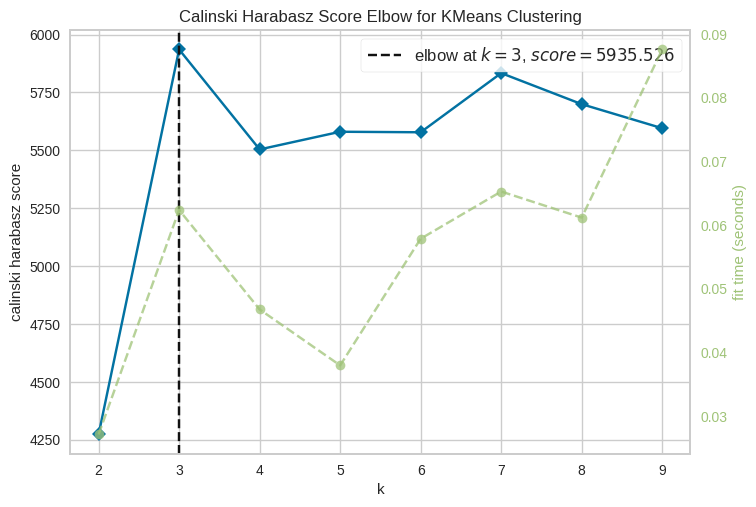

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [54]:
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,10), metric='calinski_harabasz')

visualizer.fit(model_data)  # Fit the data to the visualizer
visualizer.show()

In [55]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(model_data)

KMeans(n_clusters=3, random_state=0)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


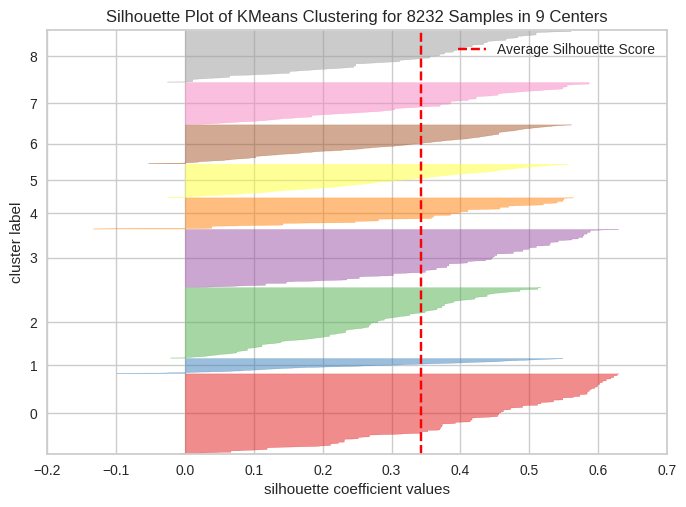

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 8232 Samples in 9 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [56]:
#SilhouetteVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

visualizer = SilhouetteVisualizer(model)

visualizer.fit(model_data)    # Fit the data to the visualizer
visualizer.poof()

In [57]:
kmeans.labels_

array([1, 2, 1, ..., 2, 0, 0], dtype=int32)

In [58]:
#append dataframe with cluster number
model_data['cluster'] = kmeans.labels_

In [59]:
kmeans.labels_ == 0

array([False, False, False, ..., False,  True,  True])

In [60]:
#view proterties of each cluster
cluster1=model_data.query("cluster == 0")
cluster2=model_data.query("cluster == 1")
cluster3=model_data.query("cluster == 2")


In [61]:
cluster1.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,cluster
253,1,14.0,0,0,0,1,0,161.28,19.1,0,0,0,0
261,0,37.0,0,0,1,2,0,162.96,39.4,2,0,3,0
273,0,59.0,0,0,1,2,1,109.82,23.7,2,0,3,0
280,0,47.0,0,0,1,2,1,103.26,25.4,0,0,3,0
283,0,58.0,0,0,1,2,1,149.75,27.0,0,0,3,0


In [62]:
cluster1.shape

(2124, 13)

In [63]:
cluster2.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,cluster
249,1,3.0,0,0,0,4,0,95.12,18.0,0,0,1,1
251,0,8.0,0,0,0,2,1,110.89,17.6,0,0,1,1
257,0,32.0,0,0,1,2,0,77.67,32.3,3,0,5,1
262,0,37.0,0,0,1,2,0,73.50,26.1,1,0,3,1
263,0,40.0,0,0,1,2,0,95.04,42.4,2,0,3,1


In [64]:
cluster2.shape

(2292, 13)

In [65]:
cluster2.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,cluster
count,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.000000,2292.0
mean,0.373473,23.921955,0.030541,0.001745,0.384817,2.511780,0.489529,85.776449,26.310602,1.179319,0.106894,2.873909,1.0
std,0.483832,13.376011,0.172108,0.041748,0.486658,1.132181,0.499999,16.926657,6.979090,1.139984,0.309045,1.827641,0.0
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000,1.0
25%,0.000000,13.000000,0.000000,0.000000,0.000000,2.000000,0.000000,73.825000,21.000000,0.000000,0.000000,1.000000,1.0
50%,0.000000,25.000000,0.000000,0.000000,0.000000,2.000000,0.000000,84.225000,25.400000,1.000000,0.000000,3.000000,1.0
75%,1.000000,36.250000,0.000000,0.000000,1.000000,4.000000,1.000000,96.795000,30.400000,2.000000,0.000000,5.000000,1.0
max,1.000000,47.000000,1.000000,1.000000,1.000000,4.000000,1.000000,146.970000,46.300000,3.000000,1.000000,5.000000,1.0


In [66]:
cluster3.shape

(3816, 13)

In [67]:
kmeans.cluster_centers_

array([[4.80225989e-01, 6.05670245e+01, 1.43126177e-01, 1.41713748e-01,
        8.78060264e-01, 1.88888889e+00, 5.20244821e-01, 1.21540570e+02,
        2.95313089e+01, 1.55461394e+00, 6.22881356e-01, 3.57391714e+00],
       [3.73472949e-01, 2.39219546e+01, 3.05410122e-02, 1.74520070e-03,
        3.84816754e-01, 2.51178010e+00, 4.89528796e-01, 8.57764485e+01,
        2.63106021e+01, 1.17931937e+00, 1.06893543e-01, 2.87390925e+00],
       [3.83909853e-01, 6.66813417e+01, 2.18815514e-01, 9.72222222e-02,
        8.62945493e-01, 2.01755765e+00, 5.13626834e-01, 7.91751310e+01,
        2.89669549e+01, 1.56865828e+00, 6.67714885e-01, 3.61556604e+00]])

In [68]:
cluster1_mean = kmeans.cluster_centers_[0]
cluster2_mean = kmeans.cluster_centers_[1]
cluster3_mean = kmeans.cluster_centers_[2]

In [69]:
cluster1.keys()

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'age_group', 'cluster'],
      dtype='object')

In [70]:
len(cluster1.keys())

13

In [71]:
cluster1_mean_p1 = cluster1_mean[:8]

In [72]:
cluster1_mean_p1

array([  0.48022599,  60.56702448,   0.14312618,   0.14171375,
         0.87806026,   1.88888889,   0.52024482, 121.54056968])

In [73]:
cluster2_mean_p1 = cluster2_mean[:8]
cluster2_mean_p1

array([3.73472949e-01, 2.39219546e+01, 3.05410122e-02, 1.74520070e-03,
       3.84816754e-01, 2.51178010e+00, 4.89528796e-01, 8.57764485e+01])

In [74]:
cluster3_mean_p1 = cluster3_mean[:8]
cluster3_mean_p1

array([ 0.38390985, 66.68134172,  0.21881551,  0.09722222,  0.86294549,
        2.01755765,  0.51362683, 79.17513103])

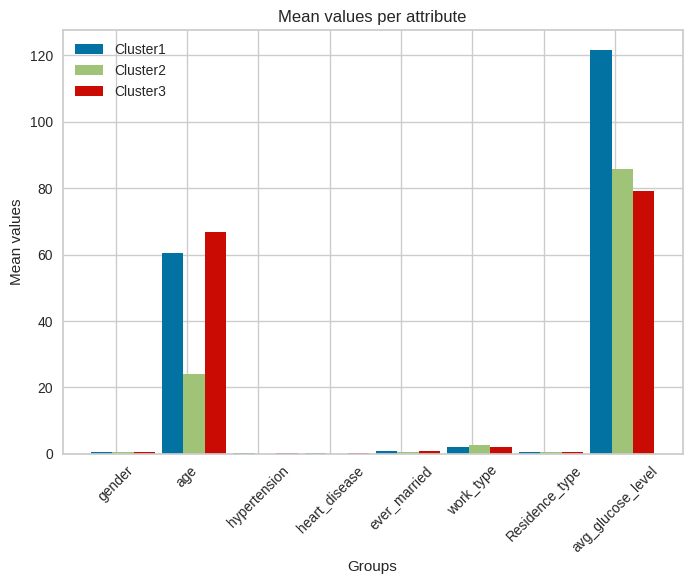

In [75]:
X = cluster1.keys()[:8]


X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, cluster1_mean_p1, 0.3, label = 'Cluster1')
plt.bar(X_axis + 0.1, cluster2_mean_p1, 0.3, label = 'Cluster2')
plt.bar(X_axis + 0.4, cluster3_mean_p1, 0.3, label = 'Cluster3')


plt.xticks(X_axis, X, rotation=45)
plt.xlabel("Groups")
plt.ylabel("Mean values")
plt.title("Mean values per attribute")
plt.legend()
plt.show()

In [95]:
cluster1_mean_p2 = cluster1_mean[8:]
cluster2_mean_p2 = cluster2_mean[8:]
cluster3_mean_p2 = cluster3_mean[8:]

In [96]:
cluster1_mean_p2

array([29.53130885,  1.55461394,  0.62288136,  3.57391714])

In [97]:
cluster2_mean_p2

array([26.31060209,  1.17931937,  0.10689354,  2.87390925])

In [98]:
cluster3_mean_p2

array([28.96695493,  1.56865828,  0.66771488,  3.61556604])

In [99]:
cluster1.keys()[8:-1]

Index(['bmi', 'smoking_status', 'stroke', 'age_group'], dtype='object')

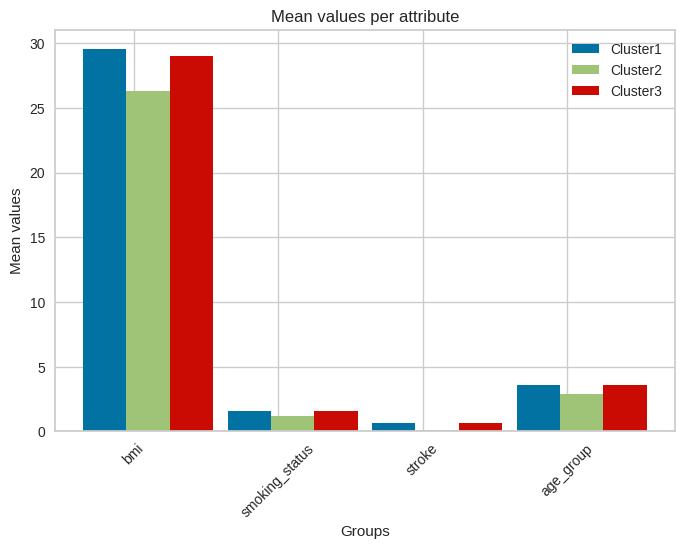

In [101]:
X = cluster1.keys()[8:-1]


X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, cluster1_mean_p2, 0.3, label = 'Cluster1')
plt.bar(X_axis + 0.1, cluster2_mean_p2, 0.3, label = 'Cluster2')
plt.bar(X_axis + 0.4, cluster3_mean_p2, 0.3, label = 'Cluster3')
plt.xticks(X_axis, X, rotation=45)
plt.xlabel("Groups")
plt.subplots_adjust(bottom=0.15, wspace=0.05)
plt.ylabel("Mean values")
plt.title("Mean values per attribute")
plt.legend()
plt.show()

## GaussianMixture

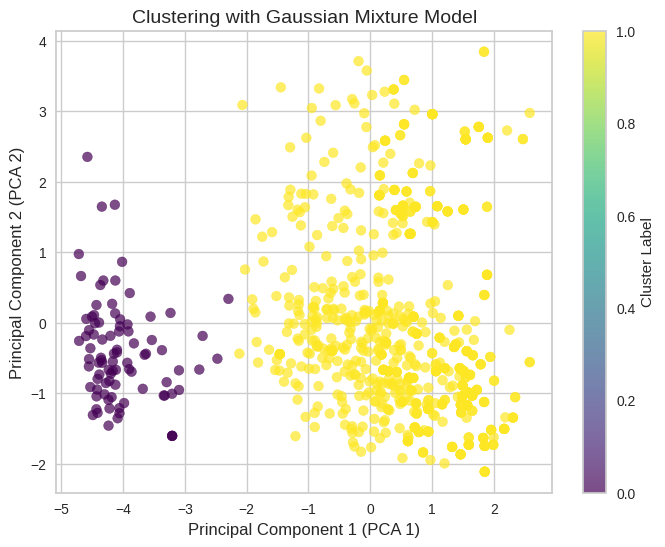

In [102]:
from sklearn.mixture import GaussianMixture  # For Gaussian Mixture Model clustering
from sklearn.decomposition import PCA        # For dimensionality reduction
from sklearn.preprocessing import StandardScaler  # For scaling features
import matplotlib.pyplot as plt              # For visualization

#Sample a subset of the data (10% of the dataset)
X = model_data.sample(frac=0.1, replace=False, random_state=42)

#Scale the features for better performance of GMM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Normalize the features to have zero mean and unit variance

#Create and fit a Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)

gmm.fit(X_scaled)

#Predict cluster labels for the dataset
labels = gmm.predict(X_scaled)

#Reduce the dataset to 2 dimensions using PCA for visualization
pca = PCA(n_components=2)  # Reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)  # Apply PCA on scaled data

#Plot the clusters in a 2D space
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

plt.title("Clustering with Gaussian Mixture Model", fontsize=14)
plt.xlabel("Principal Component 1 (PCA 1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA 2)", fontsize=12)
plt.colorbar(label="Cluster Label")  # Addding a color bar to indicate cluster labels
plt.grid(True)
plt.show()
